#Music Tagging with Deep Learning


# Getting Ready

## Preparing The Dataset
We use a subset of the Magnatagatune dataset that consists of 9074 samples with 8 seconds of audio and only 50 genres.

To make your life easier, place them in a directory as below:

```
├── annotations_final.csv
├── waveform
  ├── 1
  ├── ...
  └── d
```

In [21]:
# # Download the label file

# # this is necessary if you encounter an error message ("NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968")
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

# !gdown --id 1rNcHc2l6appY2p3VyGD7fxzzSrxPBwrh


In [1]:
# # Download the audio files
# !gdown --id 1zoJpS1-UMYFWx4NM8bgJt5wmBqsZ5_Da

In [2]:
# # uncompress the audio files
# !unzip waveform.zip

## Importing Packages

In [3]:
import warnings
import multiprocessing
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import os
import torchaudio
import torch
import torch.nn as nn
from sklearn import metrics

from tqdm.notebook import tqdm
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import IPython.display as ipd

## Enabling and Testing the GPU

First, you'll need to enable GPUs for the Colab notebook:

- Go to to the Edit menu (수정) → Notebook Settings (노트 설정)
- Select GPU from the Hardware Accelerator (하드웨어 가속기) drop-down

Next, we'll confirm that we can connect to the GPU with PyTorch and check versions of packages:

In [4]:
if not torch.cuda.is_available():
  raise SystemError('GPU device not found!')
print(f'Found GPU at: {torch.cuda.get_device_name()}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torch Audio version: {torchaudio.__version__}')

Found GPU at: NVIDIA GeForce RTX 2080 Ti
PyTorch version: 2.6.0+cu124
Torch Audio version: 2.6.0+cu124


If the cell above throws an error, then you should enable the GPU following the instruction above!

# Data Checking


In [5]:
# use 50 top tags
TAGS = ['guitar','classical', 'slow','techno','strings','drums','electronic','rock',
        'fast','piano','ambient','beat','violin','vocal','synth','female','indian',
        'opera','male','singing','vocals','no vocals','harpsichord','loud','quiet',
        'flute', 'woman', 'male vocal', 'no vocal', 'pop','soft','sitar', 'solo',
        'man', 'classic', 'choir', 'voice', 'new age', 'dance', 'male voice',
        'female vocal', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
        'metal', 'female voice', 'choral']

In [6]:
df = pd.read_csv("./annotations_final.csv", sep="\t", index_col=0)
item = df.iloc[0]
item[item != 0] # check annotated tags

classical                                                    1
strings                                                      1
opera                                                        1
violin                                                       1
mp3_path     f/american_bach_soloists-j_s__bach_solo_cantat...
Name: 2, dtype: object

In [7]:
# filter out, un-annnotated dataset
df_filter =  df[TAGS].sum(axis=1)
use_id = df_filter[df_filter != 0].index
df = df.loc[use_id]

<Axes: >

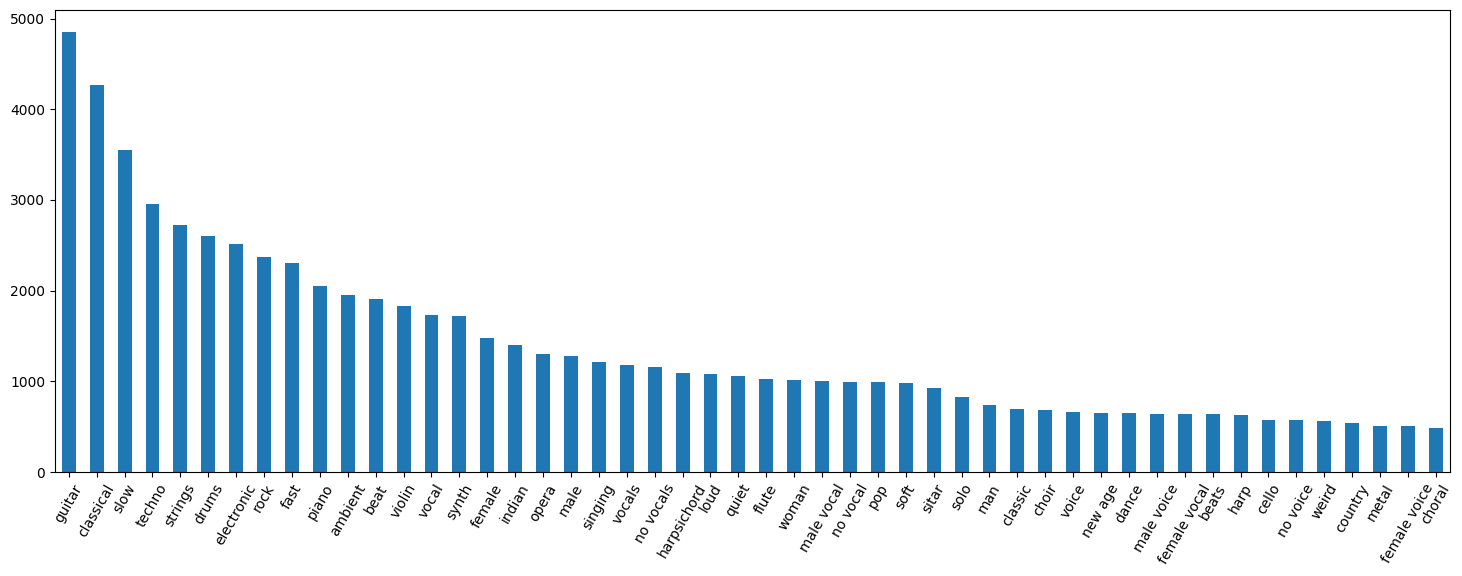

In [8]:
df[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

In [9]:
len(df)

21111

In [10]:
sample_item = df.loc[54327] # sample id
waveform = np.load(os.path.join("./waveform",sample_item['mp3_path'].replace(".mp3",".npy")))
print("annotation tag: ",list(sample_item[sample_item == 1].index))
ipd.Audio(waveform, rate=16000) # load a NumPy array

annotation tag:  ['classical', 'guitar', 'solo', 'strings', 'classical guitar', 'spanish', 'slow']


# Baseline: Training an 1D CNN model from Scratch

This baseline code is provided so that you can easily start the homework and also compare with your own algorithm.
The baseline model extracts mel-spectrogram and has a simple set of 1D CNN model that includes 1D convolutional layers, batch normalization, max-pooling and fully-connected layer.

## Data Preprocessing

In [11]:
train = []
valid = []
test = []
id_to_path = {}
for idx in range(len(df)):
  item = df.iloc[idx]
  id = item.name
  path = item['mp3_path']
  folder = path.split("/")[0]
  id_to_path[id] = path
  if folder in "012ab":
    train.append(id)# split = "train"
  elif folder == "c":
    valid.append(id)# split = "valid"
  elif folder in "d":
    test.append(id)# split = "test"

In [12]:
total = len(train) + len(valid) + len(test)
total, len(train) / total, len(valid)/ total, len(test)/ total

(9074, 0.6839321137315406, 0.16850341635441923, 0.14756446991404013)

In [13]:
df = df[TAGS]

In [14]:
df_train = df.loc[train]
df_valid = df.loc[valid]
df_test = df.loc[test]

In [15]:
# Data processing setup.
SR = 16000
BATCH_SIZE = 16

## Dataset & DataLoader

In [16]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

class AudioDataset(Dataset):
  def __init__(self, paths, input_length, binary, id_to_path, split):
    self.paths = paths
    self.input_length = input_length
    self.binary = binary
    self.id_to_path = id_to_path
    self.split = split

  def __getitem__(self, index):
    item = self.binary.iloc[index]
    waveform = self.item_to_waveform(item)
    return waveform.astype(np.float32), item.values.astype(np.float32)

  def item_to_waveform(self, item):
    id = item.name
    path = os.path.join(self.paths, self.id_to_path[id].replace(".mp3", ".npy")) # pre-extract waveform, for fast loader
    waveform = np.load(path)
    if self.split in ['TRAIN','VALID']:
      random_idx = np.random.randint(low=0, high=int(waveform.shape[0] - self.input_length))
      waveform = waveform[random_idx:random_idx+self.input_length] # extract input
      audio = np.expand_dims(waveform, axis = 0)# 1 x samples
    elif self.split == 'TEST':
      chunk_number = waveform.shape[0] // self.input_length
      chunk = np.zeros((chunk_number, self.input_length))
      for idx in range(chunk.shape[0]):
        chunk[idx] = waveform[idx:idx+input_length]
      audio = chunk
    return audio

  def __len__(self):
    return len(self.binary)

### Computing statistics of the training set
The code below compute mean, standard deviation and the minimum temporal dimension size, and use them for preprocessing inputs.

In [17]:
BATCH_SIZE = 16
num_workers = 2
sample_rate = 16000
duration = 3
input_length =  sample_rate * duration
data_path = "./waveform"
tr_data = AudioDataset(data_path, input_length, df_train, id_to_path, 'TRAIN')
va_data = AudioDataset(data_path, input_length, df_valid, id_to_path, 'VALID')
te_data = AudioDataset(data_path, input_length, df_test, id_to_path, 'TEST')
loader_train = DataLoader(tr_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=True)
loader_valid = DataLoader(va_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, drop_last=False)
loader_test = DataLoader(te_data, batch_size=1, shuffle=False, num_workers=num_workers, drop_last=False)

## Training the 1D CNN model
The table below shows the architecture of the baseline model

| Layer          | Output Size | Details                 |
|----------------|-------------|-------------------------|
| input          | B x 1 x 16000 * sec,    | batch x channel x samples |
| mel_spec       | B x 96 x 188    | batch x freq x time|
| conv + maxpool | B x 32 x 64    | kernel_size=3, stride=1 |
| conv + maxpool | B x 32 x 22    | kernel_size=3, stride=1 |
| conv + maxpool | B x 32 x 8     | kernel_size=3 stride=1 |
| global_avgpool | B x 32 x 1     | -                       |
| classifier     | B x 50         | -                       |



The folloing code implements the baseline model in PyTorch

In [18]:
import torch.nn as nn

class Baseline(nn.Module):
    def __init__(self,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(Baseline, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)

        self.conv0 = nn.Sequential(
            nn.Conv1d(n_mels, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.conv1 = nn.Sequential(
            nn.Conv1d(32, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.conv2 = nn.Sequential(
            nn.Conv1d(32, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )
        # Aggregate features over temporal dimension.
        self.final_pool = nn.AdaptiveAvgPool1d(1)
        # Predict tag using the aggregated features.
        self.linear = nn.Linear(32, n_class)

    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)
        x = x.squeeze(1) # for 1D conv
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.final_pool(x)
        x = self.linear(x.squeeze(-1))
        x = nn.Sigmoid()(x) # for binary cross entropy loss
        return x

In [19]:
class Runner(object):
  def __init__(self, model, lr, momentum, weight_decay, sr, tags):
    self.optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=True, weight_decay=weight_decay)
    self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.2, patience=5, verbose=True)
    self.learning_rate = lr
    self.stopping_rate = sr
    self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    self.model = model.to(self.device)
    self.criterion = torch.nn.BCELoss().to(self.device)
    self.tags = tags

  # Running model for train, test and validation. mode: 'train' for training, 'eval' for validation and test
  def run(self, dataloader, epoch, mode='TRAIN'):
    self.model.train() if mode is 'TRAIN' else self.model.eval()

    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f'{mode} Epoch {epoch:02}')  # progress bar
    for x, y in pbar:
      # Move mini-batch to the desired device.
      x = x.to(self.device)
      y = y.to(self.device)
      # Feed forward the model.
      prediction = self.model(x)
      # Compute the loss.
      loss = self.criterion(prediction, y)
      if mode is 'TRAIN':
        # Perform backward propagation to compute gradients.
        loss.backward()
        # Update the parameters.
        self.optimizer.step()
        # Reset the computed gradients.
        self.optimizer.zero_grad()

      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
    epoch_loss = epoch_loss / len(dataloader.dataset)
    return epoch_loss

  def test(self, dataloader):
    self.model.eval()
    epoch_loss = 0
    predictions = []
    labels = []
    pbar = tqdm(dataloader, desc=f'TEST')  # progress bar
    for x, y in pbar:
      x = x.to(self.device)
      y = y.to(self.device)
      x = x.transpose(1,0) # pre-batch in audio loader (chunk, 1, waveform)
      prediction = self.model(x)
      prediction = prediction.mean(dim=0, keepdim=True) # average chunk audio
      loss = self.criterion(prediction, y)
      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
      predictions.extend(prediction.detach().cpu().numpy())
      labels.extend(y.detach().cpu().numpy())
    epoch_loss = epoch_loss / len(loader_test.dataset)
    roc_aucs, pr_aucs, tag_wise_rocaucs = self.get_auc(predictions, labels)
    return roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs

  # Early stopping function for given validation loss
  def early_stop(self, loss, epoch):
    self.scheduler.step(loss, epoch)
    self.learning_rate = self.optimizer.param_groups[0]['lr']
    stop = self.learning_rate < self.stopping_rate
    return stop

  def get_auc(self, predictions, labels):
    roc_aucs = metrics.roc_auc_score(labels, predictions, average='macro')
    pr_aucs = metrics.average_precision_score(labels, predictions, average='macro')
    tag_wise_predictions = np.stack(predictions).T
    tag_wise_labels = np.stack(labels).T
    tag_wise_rocaucs = {}
    for tag, logit, label in zip(self.tags, tag_wise_predictions, tag_wise_labels):
      tag_wise_rocaucs[tag] = metrics.roc_auc_score(label, logit)
    return roc_aucs, pr_aucs, tag_wise_rocaucs

In [20]:
# Training setup.
LR = 1e-3  # learning rate
SR = 1e-5  # stopping rate
MOMENTUM = 0.9
NUM_EPOCHS = 10 # increase the epoch for your experiment
WEIGHT_DECAY = 0.0  # L2 regularization weight

In [22]:
# Iterate over epochs.
model = Baseline()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)
for epoch in range(NUM_EPOCHS):
  train_loss = runner.run(loader_train, epoch, 'TRAIN')
  valid_loss = runner.run(loader_valid, epoch, 'VALID')
  print("[Epoch %d/%d] [Train Loss: %.4f] [Valid Loss: %.4f]" %
        (epoch + 1, NUM_EPOCHS, train_loss, valid_loss))
  if runner.early_stop(valid_loss, epoch + 1):
    break

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/10] [Train Loss: 0.6053] [Valid Loss: 0.5029]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

VALID Epoch 08:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 9/10] [Train Loss: 0.2229] [Valid Loss: 0.2218]


TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/10] [Train Loss: 0.2205] [Valid Loss: 0.2199]


In [23]:
roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs = runner.test(loader_test)
print(f'test_loss={epoch_loss},  roc_auc={roc_aucs}, pr_auc={pr_aucs}')

TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.4379226945179269,  roc_auc=0.6265311066200044, pr_auc=0.13265650566969833


<Axes: >

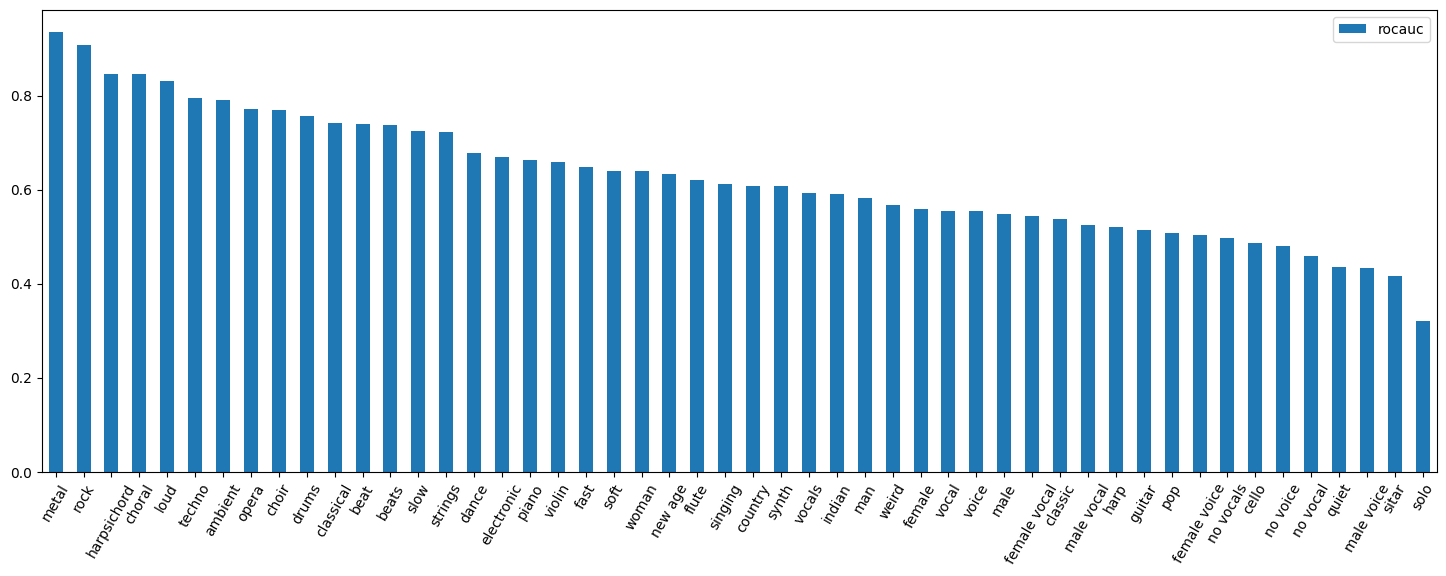

In [24]:
result_auc = pd.DataFrame([tag_wise_rocaucs[tag] for tag in TAGS], columns=['rocauc'], index=TAGS)
result_auc.sort_values(by='rocauc', ascending=False).plot.bar(figsize=(18,6),rot=60) # which tag is easy and hard task

In [25]:
def auto_tagging(waveform, model, input_length, tags, topk):
  device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
  model = model.to(device)
  chunk_number = waveform.shape[0] // input_length
  chunk = np.zeros((chunk_number, input_length))
  for idx in range(chunk.shape[0]):
    chunk[idx] = waveform[idx:idx+input_length]
  audio_tensor = torch.from_numpy(chunk.astype(np.float32))
  predictions = model(audio_tensor.unsqueeze(1).to(device))
  logit = predictions.mean(dim=0, keepdim=False).detach().cpu().numpy()
  annotation = [tags[i] for i in logit.argsort()[::-1][:topk]]
  return annotation

In [26]:
# sample infernece id = 234
id = 234
audio_sample = df_test.loc[id]
waveform = np.load(os.path.join("./waveform",id_to_path[id].replace(".mp3",".npy")))
print("annotation tag: ",list(audio_sample[audio_sample != 0].index))
ipd.Audio(waveform, rate=16000) # load a NumPy array

annotation tag:  ['guitar', 'techno', 'rock', 'fast', 'synth']


In [27]:
annotation = auto_tagging(waveform, runner.model, input_length, TAGS, 5)
print("model predict tags: ",annotation)

model predict tags:  ['guitar', 'techno', 'electronic', 'drums', 'rock']


### [Question 1] Implement a 2D CNN architecture.
Implement a 2D CNN with the folloing configuration.

| Layer          | Output Size | Details                 |
|----------------|-------------|-------------------------|
| input          | B x 1 x sample_rate * duration,    | batch x channel (mono) x samples |
| mel_spec       | B x 1 x 96 x 188    | batch x channel (mono) x freq x time|
| conv + maxpool | B x 64 x 24 x 47    | output_channels=64, kernel_size=3, pooling=(4,4) |
| conv + maxpool | B x 128 x 8 x 15    | output_channels=128, kernel_size=3, pooling=(3,3) |
| conv + maxpool | B x 128 x  2 x 5     | output_channels=128, kernel_size=3 pooling=(3,3) |
| conv + maxpool | B x 64 x 1 x 1      | output_channels=64, kernel_size=3 pooling=(2,5)                    |
| classifier     | B x 50         | -                       |


Note: you should give appropriate paddings!

The folowing is the startup code. Fill in the "to-do" area.

In [34]:
import torch.nn as nn

class Conv_2d(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=3, stride=1, padding=1, pooling=2):
        super(Conv_2d, self).__init__()
        # To do
        #========================================
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU()
        self.mp = nn.MaxPool2d(kernel_size=pooling)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.mp(out)
        return out
    #========================================

class CNN2D(nn.Module):
    def __init__(self,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(CNN2D, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)
        # To do
        #========================================
        self.layer1 = Conv_2d(input_channels=1, output_channels=64, kernel_size=3, stride=1, padding=1, pooling=(4, 4))
        self.layer2 = Conv_2d(input_channels=64, output_channels=128, kernel_size=3, stride=1, padding=1, pooling=(3, 3))
        self.layer3 = Conv_2d(input_channels=128, output_channels=128, kernel_size=3, stride=1, padding=1, pooling=(3, 3))
        self.layer4 = Conv_2d(input_channels=128, output_channels=64, kernel_size=3, stride=1, padding=1, pooling=(2, 5))
        #========================================
        self.linear = nn.Linear(64, n_class)
    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        x = nn.Sigmoid()(x) # for binary cross entropy loss
        return x

### [Question 2] Improve the performenace.
Now it is your turn. You can improve the model performance with your own idea.

In [35]:
# Iterate over epochs.
model = CNN2D()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)
for epoch in range(NUM_EPOCHS):
  train_loss = runner.run(loader_train, epoch, 'TRAIN')
  valid_loss = runner.run(loader_valid, epoch, 'VALID')
  print("[Epoch %d/%d] [Train Loss: %.4f] [Valid Loss: %.4f]" %
        (epoch + 1, NUM_EPOCHS, train_loss, valid_loss))
  if runner.early_stop(valid_loss, epoch + 1):
    break

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/10] [Train Loss: 0.3322] [Valid Loss: 0.2232]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

VALID Epoch 08:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 9/10] [Train Loss: 0.1921] [Valid Loss: 0.1912]


TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/10] [Train Loss: 0.1908] [Valid Loss: 0.1897]


In [36]:
roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs = runner.test(loader_test)
print(f'test_loss={epoch_loss},  roc_auc={roc_aucs}, pr_auc={pr_aucs}')

TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.3858092619444204,  roc_auc=0.7518622478247168, pr_auc=0.23256918583331804


<Axes: >

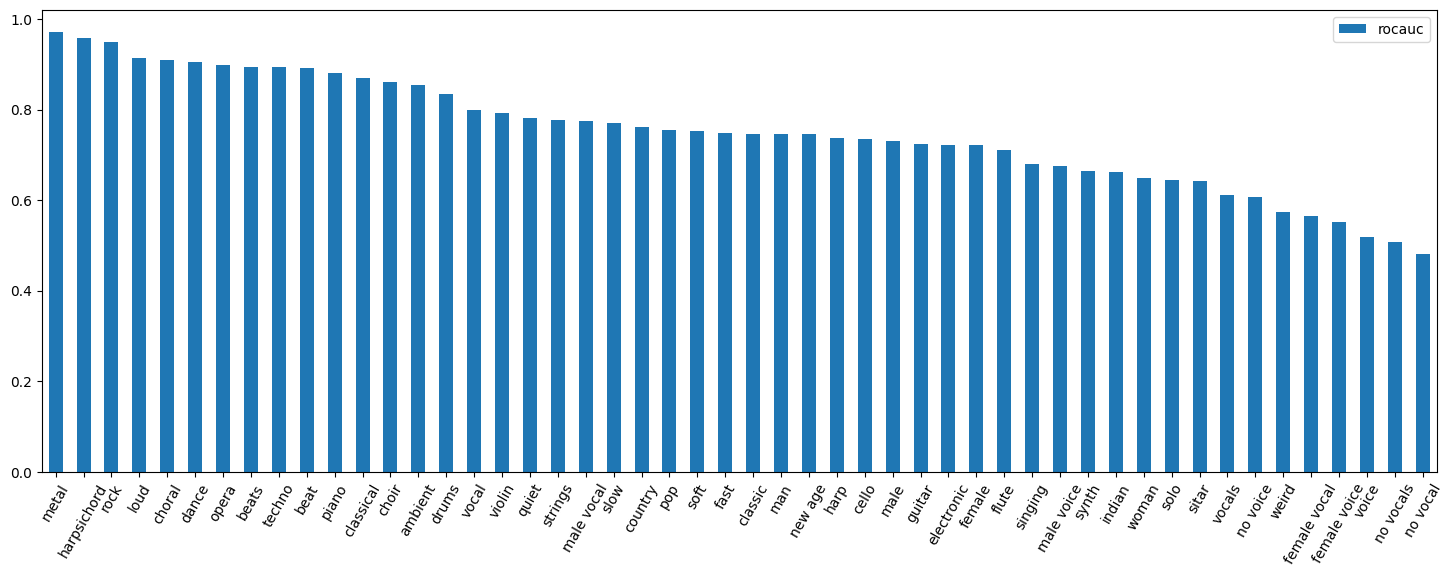

In [37]:
result_auc = pd.DataFrame([tag_wise_rocaucs[tag] for tag in TAGS], columns=['rocauc'], index=TAGS)
result_auc.sort_values(by='rocauc', ascending=False).plot.bar(figsize=(18,6),rot=60) # which tag is easy and hard task

# Credit
This homework was implemented and improved by Jongpil Lee, Soonbeom Choi, Taejun Kim, SeungHeon Doh, and Juhan Nam from the KAIST Music and Audio Computing Lab.
